The signature analyzed were the pigmented signature (MITF, MLANA, TYR, TRPM1, DCT), the invasive signature (CCN1, LOXL2, WNT5A, TCF4, AXL, TNC), the SMC signature (CD36, DLX5, IP6K3, PAX3, TRIM67) and the NCSC-like signatures (NGFR, AQP1, GFRA2, L1CAM, SLC22A17). 

In [1]:
import pandas, seaborn
import scipy, scipy.stats
import matplotlib, matplotlib.pyplot

In [2]:
#user defined variables
annotation_file = '/Users/adrian/software/kallisto/mouse_index_standard/annotation.tsv'
expression_file = '/Users/adrian/research/bmcbf/029_orsay/results/000.quantification/results/DESeq2_TPM_values.tsv'

pigmented = ['Mitf', 'Mlana', 'Tyr', 'Trpm1', 'Dct']
invasive = ['Ccn1', 'Loxl2', 'Wnt5a', 'Tcf4', 'Axl', 'Tnc']
mesenchymal = ["Cd36", "Dlx5", "Ip6k3", "Pax3", "Trim67"]
crest = ["Ngfr", "Aqp1", "Gfra2", "L1cam", "Slc22a17"]
biomarkers = pigmented + invasive + mesenchymal + crest
print(biomarkers)

['Mitf', 'Mlana', 'Tyr', 'Trpm1', 'Dct', 'Ccn1', 'Loxl2', 'Wnt5a', 'Tcf4', 'Axl', 'Tnc', 'Cd36', 'Dlx5', 'Ip6k3', 'Pax3', 'Trim67', 'Ngfr', 'Aqp1', 'Gfra2', 'L1cam', 'Slc22a17']


In [3]:
# read info
anno = pandas.read_csv(annotation_file, sep='\t')
expression = pandas.read_csv(expression_file, sep='\t', index_col=0)

In [4]:
# manipulate expression

In [5]:
expression.index = expression.index.str.split('.').str[0]

print(expression.shape)
expression.drop(['P9T001', 'P9T004', 'P9T009'], axis=1, inplace=True)
print(expression.shape)

(34183, 34)
(34183, 31)


In [6]:
rosetta = {}
for biomarker in biomarkers:
    info = anno[anno['external_gene_name'] == biomarker]
    hit = list(info['ensembl_gene_id'].values)[0]
    print(info)
    rosetta[biomarker] = hit
print(rosetta)
biomarker_names = list(rosetta.values())

       Unnamed: 0     ensembl_gene_id external_gene_name    gene_biotype  \
14867       14868  ENSMUSG00000035158               Mitf  protein_coding   

                                             description  
14867  melanogenesis associated transcription factor ...  
      Unnamed: 0     ensembl_gene_id external_gene_name    gene_biotype  \
6150        6151  ENSMUSG00000024806              Mlana  protein_coding   

                                     description  
6150  melan-A [Source:MGI Symbol;Acc:MGI:108454]  
       Unnamed: 0     ensembl_gene_id external_gene_name    gene_biotype  \
10749       10750  ENSMUSG00000004651                Tyr  protein_coding   

                                        description  
10749  tyrosinase [Source:MGI Symbol;Acc:MGI:98880]  
      Unnamed: 0     ensembl_gene_id external_gene_name    gene_biotype  \
8131        8132  ENSMUSG00000030523              Trpm1  protein_coding   

                                            description  
8131  

In [7]:
df = expression.loc[biomarker_names]
df

,P9T002,P9T003,P9T005,P9T006,P9T007,P9T008,P9T010,P9T011,P9T012,P9T013,...,P9T025,P9T026,P9T027,P9T028,P9T029,P9T030,P9T031,P9T032,P9T033,P9T034
ENSMUSG00000035158,7.512801,6.405729,7.305249,6.643133,6.913299,8.888741,10.210440,10.092990,8.651269,6.109353,...,10.478315,7.665040,8.153597,9.618195,11.361233,8.207667,6.409286,4.214004,4.149371,5.330290
ENSMUSG00000024806,0.704414,0.255398,0.341277,0.747098,0.381372,0.062657,1.698605,2.053939,0.530988,0.903617,...,0.820800,0.295111,0.052207,0.064434,0.336831,0.143126,0.533647,0.193249,0.155346,0.210457
ENSMUSG00000004651,0.584955,1.219772,0.866577,0.354613,1.134251,0.450720,0.569789,0.712963,0.287177,0.527316,...,0.626499,0.415369,0.216342,0.834535,0.867676,0.877037,0.919191,0.392773,1.045507,0.750116
ENSMUSG00000030523,0.097092,0.000000,0.019026,0.099710,0.021604,0.064552,0.184609,0.082389,0.038668,0.176466,...,0.069524,0.145514,0.369410,0.006928,0.053218,0.122567,1.553029,0.034754,0.000000,0.068490
ENSMUSG00000022129,1.046265,0.796762,0.315734,1.484767,0.628136,1.882726,1.043484,0.646945,1.912917,0.915566,...,1.395957,0.715598,0.760160,0.936584,0.525213,0.314396,3.315621,0.989429,1.344343,0.627423
ENSMUSG00000028195,41.854779,13.949617,21.534381,33.971164,36.886932,35.962745,39.015635,74.301102,14.760937,57.405430,...,38.572160,35.324755,42.555270,31.131535,45.178771,45.084077,23.935205,38.677526,34.762255,29.862234
ENSMUSG00000034205,127.428269,83.524159,110.301883,144.944139,139.490123,159.224920,101.196317,199.585537,111.447242,152.335449,...,139.666178,99.657726,146.282779,165.771403,144.737699,136.861338,116.672383,110.188814,133.447639,128.472225
ENSMUSG00000021994,5.394625,3.342218,3.622932,5.279437,5.307266,5.272626,4.209765,7.602590,4.265779,6.958093,...,6.378780,9.015037,6.032095,5.611027,3.221633,2.957868,12.958464,5.139005,4.848122,3.888410
ENSMUSG00000053477,48.893516,80.078697,62.103519,57.202139,54.779770,59.619934,53.776789,60.495254,58.514582,46.186985,...,59.049376,55.407827,60.831833,63.695213,54.631470,57.908280,58.980182,57.320357,63.066769,63.474480
ENSMUSG00000002602,90.169050,101.067204,125.349884,84.723321,120.297287,90.980784,100.218370,118.981126,87.217604,108.215350,...,97.318984,145.667594,87.564496,144.449216,164.252603,119.334373,100.404848,96.065039,151.558811,102.978410


In [8]:
inverse_rosetta = {v: k for k, v in rosetta.items()}
print(inverse_rosetta)
df.rename(index=inverse_rosetta, inplace=True)
df

{'ENSMUSG00000035158': 'Mitf', 'ENSMUSG00000024806': 'Mlana', 'ENSMUSG00000004651': 'Tyr', 'ENSMUSG00000030523': 'Trpm1', 'ENSMUSG00000022129': 'Dct', 'ENSMUSG00000028195': 'Ccn1', 'ENSMUSG00000034205': 'Loxl2', 'ENSMUSG00000021994': 'Wnt5a', 'ENSMUSG00000053477': 'Tcf4', 'ENSMUSG00000002602': 'Axl', 'ENSMUSG00000028364': 'Tnc', 'ENSMUSG00000002944': 'Cd36', 'ENSMUSG00000029755': 'Dlx5', 'ENSMUSG00000024210': 'Ip6k3', 'ENSMUSG00000004872': 'Pax3', 'ENSMUSG00000036913': 'Trim67', 'ENSMUSG00000000120': 'Ngfr', 'ENSMUSG00000004655': 'Aqp1', 'ENSMUSG00000022103': 'Gfra2', 'ENSMUSG00000031391': 'L1cam', 'ENSMUSG00000022199': 'Slc22a17'}


,P9T002,P9T003,P9T005,P9T006,P9T007,P9T008,P9T010,P9T011,P9T012,P9T013,...,P9T025,P9T026,P9T027,P9T028,P9T029,P9T030,P9T031,P9T032,P9T033,P9T034
Mitf,7.512801,6.405729,7.305249,6.643133,6.913299,8.888741,10.210440,10.092990,8.651269,6.109353,...,10.478315,7.665040,8.153597,9.618195,11.361233,8.207667,6.409286,4.214004,4.149371,5.330290
Mlana,0.704414,0.255398,0.341277,0.747098,0.381372,0.062657,1.698605,2.053939,0.530988,0.903617,...,0.820800,0.295111,0.052207,0.064434,0.336831,0.143126,0.533647,0.193249,0.155346,0.210457
Tyr,0.584955,1.219772,0.866577,0.354613,1.134251,0.450720,0.569789,0.712963,0.287177,0.527316,...,0.626499,0.415369,0.216342,0.834535,0.867676,0.877037,0.919191,0.392773,1.045507,0.750116
Trpm1,0.097092,0.000000,0.019026,0.099710,0.021604,0.064552,0.184609,0.082389,0.038668,0.176466,...,0.069524,0.145514,0.369410,0.006928,0.053218,0.122567,1.553029,0.034754,0.000000,0.068490
Dct,1.046265,0.796762,0.315734,1.484767,0.628136,1.882726,1.043484,0.646945,1.912917,0.915566,...,1.395957,0.715598,0.760160,0.936584,0.525213,0.314396,3.315621,0.989429,1.344343,0.627423
Ccn1,41.854779,13.949617,21.534381,33.971164,36.886932,35.962745,39.015635,74.301102,14.760937,57.405430,...,38.572160,35.324755,42.555270,31.131535,45.178771,45.084077,23.935205,38.677526,34.762255,29.862234
Loxl2,127.428269,83.524159,110.301883,144.944139,139.490123,159.224920,101.196317,199.585537,111.447242,152.335449,...,139.666178,99.657726,146.282779,165.771403,144.737699,136.861338,116.672383,110.188814,133.447639,128.472225
Wnt5a,5.394625,3.342218,3.622932,5.279437,5.307266,5.272626,4.209765,7.602590,4.265779,6.958093,...,6.378780,9.015037,6.032095,5.611027,3.221633,2.957868,12.958464,5.139005,4.848122,3.888410
Tcf4,48.893516,80.078697,62.103519,57.202139,54.779770,59.619934,53.776789,60.495254,58.514582,46.186985,...,59.049376,55.407827,60.831833,63.695213,54.631470,57.908280,58.980182,57.320357,63.066769,63.474480
Axl,90.169050,101.067204,125.349884,84.723321,120.297287,90.980784,100.218370,118.981126,87.217604,108.215350,...,97.318984,145.667594,87.564496,144.449216,164.252603,119.334373,100.404848,96.065039,151.558811,102.978410


In [9]:
df_zscore = df.apply(scipy.stats.zscore, axis=1)
df_zscore

,P9T002,P9T003,P9T005,P9T006,P9T007,P9T008,P9T010,P9T011,P9T012,P9T013,...,P9T025,P9T026,P9T027,P9T028,P9T029,P9T030,P9T031,P9T032,P9T033,P9T034
Mitf,-0.451574,-1.020342,-0.558206,-0.898373,-0.759573,0.255326,0.934359,0.874018,0.133322,-1.172607,...,1.071982,-0.373360,-0.122360,0.630089,1.525588,-0.094581,-1.018514,-2.146357,-2.179563,-1.572857
Mlana,0.623282,-0.361945,-0.173511,0.716940,-0.085535,-0.784858,2.804733,3.584406,0.242752,1.060373,...,0.878657,-0.274807,-0.807788,-0.780959,-0.183267,-0.608294,0.248587,-0.498314,-0.581480,-0.460555
Tyr,-0.461685,1.621508,0.462478,-1.217566,1.340865,-0.902183,-0.511452,-0.041618,-1.438860,-0.650830,...,-0.325355,-1.018190,-1.671309,0.357329,0.466085,0.496800,0.635133,-1.092341,1.049646,0.080301
Trpm1,-0.225399,-0.554247,-0.489805,-0.216533,-0.481076,-0.335610,0.071018,-0.275199,-0.423280,0.043436,...,-0.318772,-0.061398,0.696932,-0.530783,-0.374001,-0.139118,4.705803,-0.436538,-0.554247,-0.322273
Dct,-0.071251,-0.481461,-1.272327,0.649697,-0.758703,1.303987,-0.075822,-0.727779,1.353625,-0.286134,...,0.503683,-0.614905,-0.541640,-0.251578,-0.927919,-1.274527,3.659830,-0.164695,0.418824,-0.759874
Ccn1,0.173213,-1.872767,-1.316659,-0.404806,-0.191025,-0.258785,-0.034950,2.552148,-1.813282,1.313373,...,-0.067465,-0.305562,0.224573,-0.613005,0.416926,0.409983,-1.140633,-0.059740,-0.346804,-0.706069
Loxl2,-0.328082,-1.789871,-0.898306,0.255110,0.073518,0.730589,-1.201476,2.074398,-0.860171,0.501204,...,0.079380,-1.252703,0.299680,0.948555,0.248237,-0.014007,-0.686199,-0.902070,-0.127666,-0.293323
Wnt5a,-0.086641,-1.097149,-0.958938,-0.143354,-0.129652,-0.146708,-0.670010,1.000457,-0.642431,0.683137,...,0.397910,1.695879,0.227219,0.019905,-1.156519,-1.286385,3.637436,-0.212496,-0.355713,-0.828230
Tcf4,-1.650991,2.808550,0.238065,-0.462842,-0.809246,-0.117093,-0.952674,0.008080,-0.275160,-2.038031,...,-0.198684,-0.719432,0.056211,0.465680,-0.830453,-0.361863,-0.208578,-0.445937,0.375811,0.434115
Axl,-0.834366,-0.359982,0.697016,-1.071413,0.477082,-0.799032,-0.396931,0.419791,-0.962840,-0.048831,...,-0.523138,1.581424,-0.947740,1.528389,2.390408,0.435168,-0.388813,-0.577720,1.837862,-0.276789


In [10]:
group_dict = {}

# Group A: P9T002 to P9T008 (excluding P9T004 and P9T009)
for i in range(1, 10):
    if i not in [1, 4, 9]:
        sample_id = f"P9T{i:03d}"
        group_dict[sample_id] = "WT"

# Group B: P9T010 to P9T015
for i in range(10, 19):
    sample_id = f"P9T{i:03d}"
    group_dict[sample_id] = "HET"

# Group C: P9T020 to P9T025
for i in range(19, 31):
    sample_id = f"P9T{i:03d}"
    group_dict[sample_id] = "HOM"

for i in range(31, 35):
    sample_id = f"P9T{i:03d}"
    group_dict[sample_id] = "VGA"

# # (Optional) Preview
# for element in group_dict:
#     print(element, group_dict[element])

group_series = pandas.Series(group_dict).reindex(df_zscore.columns)
group_colors = group_series.map({'WT': 'gray', 'HET': 'gold', 'HOM': 'tab:red', 'VGA': 'skyblue'})

In [11]:
row_group_dict = {}

pigmented = ['Mitf', 'Mlana', 'Tyr', 'Trpm1', 'Dct']
invasive = ['Ccn1', 'Loxl2', 'Wnt5a', 'Tcf4', 'Axl', 'Tnc']

for element in pigmented:
    row_group_dict[element] = "tab:orange"

for element in invasive:
    row_group_dict[element] = "pink"

for element in mesenchymal:
    row_group_dict[element] = "skyblue"

for element in crest:
    row_group_dict[element] = "gray"

# Create a row color series from the row group dictionary
row_colors = pandas.Series(row_group_dict)

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

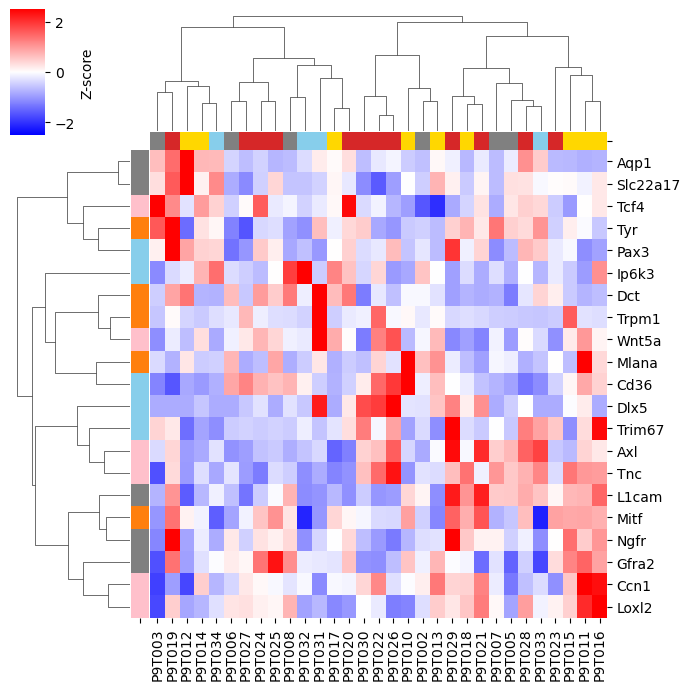

In [12]:
g = seaborn.clustermap(
    df_zscore,
    metric='correlation',     # distance metric
    method='complete',       # clustering method (e.g., single, complete, average, ward)
    cmap='bwr',            # color map (others: 'coolwarm', 'viridis', 'mako', 'rocket')
    standard_scale=None,    # or 0 (rows) or 1 (columns) if you didn't z-score earlier
    figsize=(7, 7),
    col_colors=group_colors,
    row_colors=row_colors,
    dendrogram_ratio=(0.2, 0.2),  # adjust size of dendrograms
    cbar_pos=(0.02, 0.8, 0.05, 0.18),  # colorbar position
    xticklabels=True,
    cbar_kws={'label': 'Z-score'},
    vmin=-2.5,
    vmax=2.5,
    yticklabels=True
)
matplotlib.pyplot.setp(g.ax_heatmap.get_yticklabels(), rotation=0)
